# importing dataset

In [26]:
!kaggle datasets download -d mohammadhossein77/brain-tumors-dataset


Dataset URL: https://www.kaggle.com/datasets/mohammadhossein77/brain-tumors-dataset
License(s): CC0-1.0
100% 221M/221M [00:11<00:00, 20.2MB/s]



In [28]:
!pip install patool


#unzipping and extracting the dataset in new folder

In [29]:
import patoolib
patoolib.extract_archive("/content/brain-tumors-dataset.zip")


INFO patool: Extracting /content/brain-tumors-dataset.zip ...
INFO patool: running /usr/bin/7z x -aou -o/content/Unpack_v6al8px9 -- /content/brain-tumors-dataset.zip
INFO patool: ... /content/brain-tumors-dataset.zip extracted to `Data'.


'Data'

#importing modules

In [30]:
import io
import os
import cv2
import keras
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from keras.models import Sequential
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout


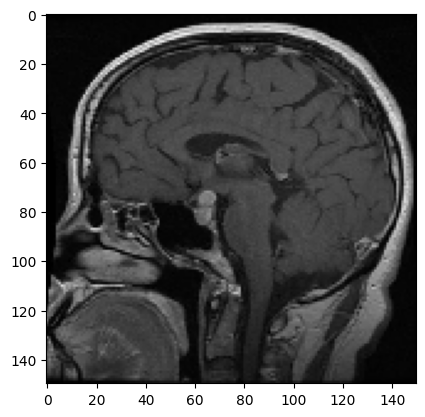

In [31]:
from tensorflow.keras.preprocessing import image
img=image.load_img('/content/Data/Tumor/pituitary_tumor/P_150.jpg',target_size=(150,150))
plt.imshow(img)


#image preprocessing


In [32]:
x=[]
y=[]
a=0
b=0
c=0
d=0
ims=150
tu=['glioma_tumor','meningioma_tumor','pituitary_tumor']
no=['Normal']
normal=os.path.join('/content/Data/Normal')
for j in os.listdir(normal):
  img=cv2.imread(os.path.join(normal,j))
  img=cv2.resize(img,(ims,ims))
  x.append(img)
  y.append('normal')
  a=a+1

for i in tu:
  tumor=os.path.join('/content/Data/Tumor',i)
  for j in os.listdir(tumor):
    img=cv2.imread(os.path.join(tumor,j))
    img=cv2.resize(img,(ims,ims))
    x.append(img)
    y.append(i)
    if i=='glioma_tumor':
      b=b+1
    elif i=='meningioma_tumor':
      c=c+1
    else:
      d=d+1


In [33]:
import os
from collections import Counter

# Path to your dataset
dataset_path = '/content/Data'

# Categories and subcategories
categories = ['Tumor', 'Normal']
tumor_subcategories = ['glioma_tumor', 'pituitary_tumor', 'meningioma_tumor']

# Initialize a Counter to count images
image_count = Counter()

# Count images in Tumor Images subfolder
for subcategory in tumor_subcategories:
    subcategory_path = os.path.join(dataset_path, 'Tumor', subcategory)
    image_count[subcategory] = len(os.listdir(subcategory_path))

# Count images in Normal Images subfolder
normal_images_path = os.path.join(dataset_path, 'Normal')
image_count['Normal Images'] = len(os.listdir(normal_images_path))

# Display the counts
print(image_count)


Counter({'meningioma_tumor': 6391, 'glioma_tumor': 6307, 'pituitary_tumor': 5908, 'Normal Images': 3066})


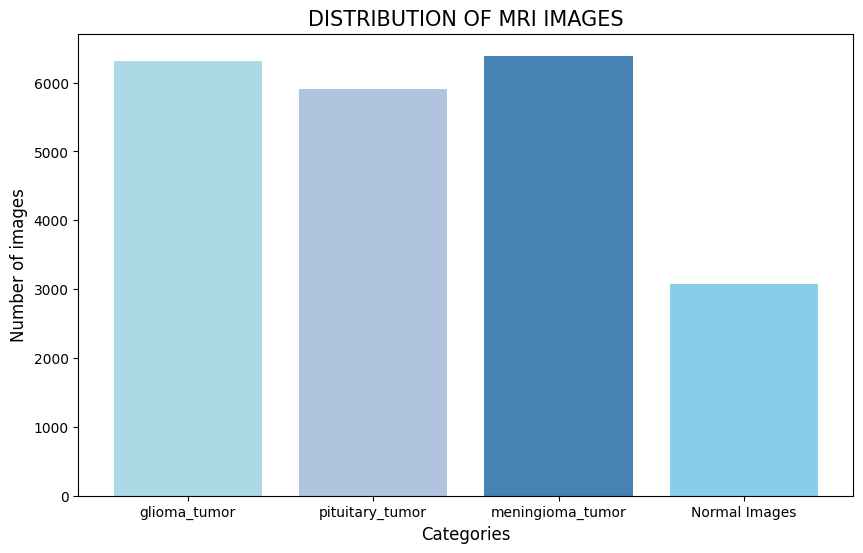

In [34]:
import matplotlib.pyplot as plt

# Labels and counts
labels = list(image_count.keys())
counts = list(image_count.values())

# Plotting the distribution
plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color=['lightblue', 'lightsteelblue', 'steelblue', 'skyblue'])
plt.title('DISTRIBUTION OF MRI IMAGES',size=15)
plt.xlabel('Categories',size=12,font='lexend')
plt.ylabel('Number of images',size=12,font='lexend')
plt.show()


#converting to numpy array

In [35]:
x=np.array(x)
y=np.array(y)


#shuffling

In [36]:
x,y=shuffle(x,y,random_state=101)


#train test split

In [37]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=101)


In [38]:
ytrn=[]
for i in ytrain:
  if i=='glioma_tumor':
    ytrn.append(0)

  elif i=='meningioma_tumor':
    ytrn.append(1)
  elif i=='pituitary_tumor':
    ytrn.append(2)
  else:
    ytrn.append(3)

ytrain=ytrn
ytrain=tf.keras.utils.to_categorical(ytrain)


In [39]:
yten=[]
for i in ytest:
  if i=='glioma_tumor':
    yten.append(0)
  elif i=='meningioma_tumor':
    yten.append(1)
  elif i=='pituitary_tumor':
    yten.append(2)
  else:
    yten.append(3)

ytest=yten
yte=tf.keras.utils.to_categorical(ytest)


#model creation

In [40]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.summary( )


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 69, 69, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 30, 30, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 13, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    15,860,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,297,188 (65.98 MB)

 Trainable params: 17,297,188 (65.98 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])


#training

In [43]:
model.fit(xtrain,ytrain,epochs=10,validation_split=(0.1))


Epoch 1/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 46s 70ms/step - accuracy: 0.6082 - loss: 0.9720 - val_accuracy: 0.7757 - val_loss: 0.5654
Epoch 2/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 30s 62ms/step - accuracy: 0.8246 - loss: 0.4583 - val_accuracy: 0.8766 - val_loss: 0.3325
Epoch 3/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.9155 - loss: 0.2418 - val_accuracy: 0.9250 - val_loss: 0.2026
Epoch 4/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9530 - loss: 0.1382 - val_accuracy: 0.9366 - val_loss: 0.2111
Epoch 5/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9664 - loss: 0.0986 - val_accuracy: 0.9400 - val_loss: 0.1979
Epoch 6/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.9753 - loss: 0.0741 - val_accuracy: 0.9239 - val_loss: 0.2719
Epoch 7/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.9847 - loss: 0.0527 - val_accuracy: 0.9446 - val_loss: 0.2528
Epoch 8/10
488/488 ━━━━━━━━━━━━━━━━━━━━ 29s 60ms/step - accuracy: 0.9840 - loss: 0.0501 - 

In [44]:
model.save('brain_tumor.keras')


#testing

In [45]:
ypred=model.predict(xtest)

# Convert predictions to 1D array of predicted classes
ypred_classes = np.argmax(ypred,axis=1)

df=pd.DataFrame({'Actual':ytest,'Predicted':ypred_classes})
df


136/136 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step


,Actual,Predicted
0,2,2
1,3,3
2,1,1
3,2,2
4,2,2
...,...,...
4330,0,0
4331,3,3
4332,1,1
4333,2,2


#testing with new image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
normal


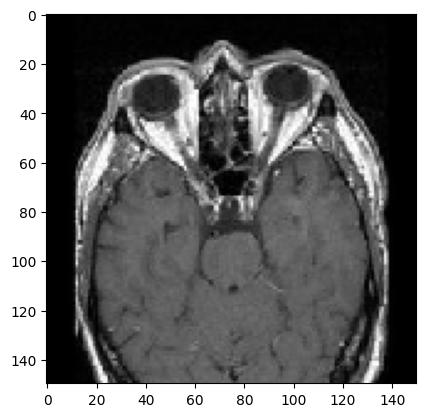

In [46]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
img=image.load_img('/content/Data/Normal/N_1.jpg',target_size=(150,150))
plt.imshow(img)
ai=cv2.imread(f"/content/Data/Normal/N_1.jpg")
ai=cv2.resize(ai,(150,150))
ai=np.array(ai)
ai=ai.reshape((1,150,150,3))
a=model.predict(ai)
index=a.argmax()
if(index==0):
  print('glioma')
elif(index==1):
  print('meningioma')
elif(index==2):
  print('pituitary')
else:
  print('normal')


#graph plottting

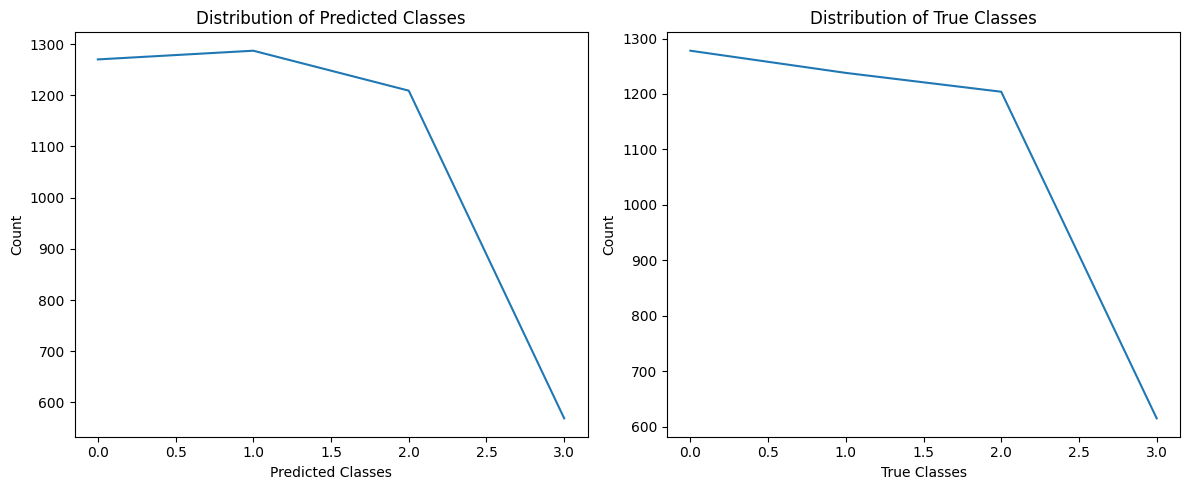

In [47]:
import matplotlib.pyplot as plt

# Assuming 'ypred_classes' contains predicted class labels and 'ytest' contains true class labels
# Count occurrences of each class
unique_predicted, counts_predicted = np.unique(ypred_classes, return_counts=True)
unique_true, counts_true = np.unique(ytest, return_counts=True)

# Create bar plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(unique_predicted, counts_predicted)
plt.xlabel('Predicted Classes')
plt.ylabel('Count')
plt.title('Distribution of Predicted Classes')

plt.subplot(1, 2, 2)
plt.plot(unique_true, counts_true)
plt.xlabel('True Classes')
plt.ylabel('Count')
plt.title('Distribution of True Classes')

plt.tight_layout()
plt.show()
